In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Monte Carlo a estirmativa foi de : 0.500203
Valor Analítico Real: 0.500000


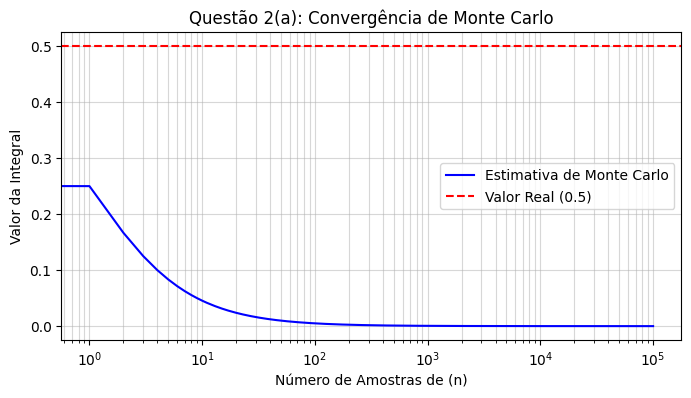

In [ ]:
#(a) Estime via Monte Carlo simples, usando a uniforme.
#Parametros
N = 100000
valor_real = 0.5
# geraracao de amostras da uniforme U(0,1)
u = np.random.uniform(0, 1, N)
gu = (1 / (1 + u)**2)

#estimativa de Monte Carlo
estimativa_mc = np.mean (gu)
print(f"Monte Carlo a estirmativa foi de : {estimativa_mc:.6f}")
print(f"Valor Analítico Real: {valor_real:.6f}")
medias_acumuladas = np.cumsum(estimativa_mc) / np.arange(1, N + 1)
plt.figure(figsize=(8, 4))
plt.plot(medias_acumuladas, color='blue', label='Estimativa de Monte Carlo')
plt.axhline(y=valor_real, color='red', linestyle='--', label=f'Valor Real ({valor_real})')
plt.title('Questão 2(a): Convergência de Monte Carlo')
plt.xlabel('Número de Amostras de (n)')
plt.ylabel('Valor da Integral')
plt.xscale('log') #  para melhor visualização
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

Estimativa final: 0.499950


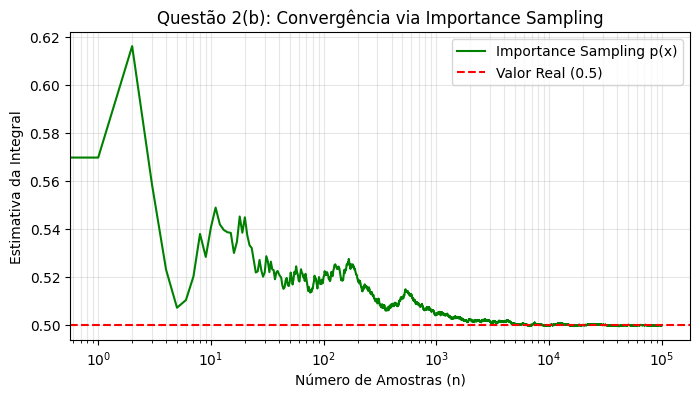

In [ ]:
#(b) Escolha uma distribuição p(x).
# parametros
N = 100000
valor_real = 0.5  

# Gerar amostras de p(x) via Inversa 
u = np.random.uniform(0, 1, N)
x_is = 2 - np.sqrt(4 - 3 * u)

# Calcular a média de f(x)/p(x) 
f_x = 1 / (1 + x_is)**2
p_x = (2/3) * (2 - x_is)
razao = f_x / p_x
estimativa_is = np.mean(razao)
print(f"Estimativa final: {estimativa_is:.6f}")

# Gráfico 
medias_acumuladas = np.cumsum(razao) / np.arange(1, N + 1)
plt.figure(figsize=(8, 4))
plt.plot(medias_acumuladas, color='green', label='Importance Sampling p(x)')
plt.axhline(y=valor_real, color='red', linestyle='--', label=f'Valor Real ({valor_real})')
plt.xscale('log') 
plt.title('Questão 2(b): Convergência via Importance Sampling')
plt.xlabel('Número de Amostras (n)')
plt.ylabel('Estimativa da Integral')
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

Estimativa MC Simples: 0.499188
Estimativa Importance Sampling: 0.500130


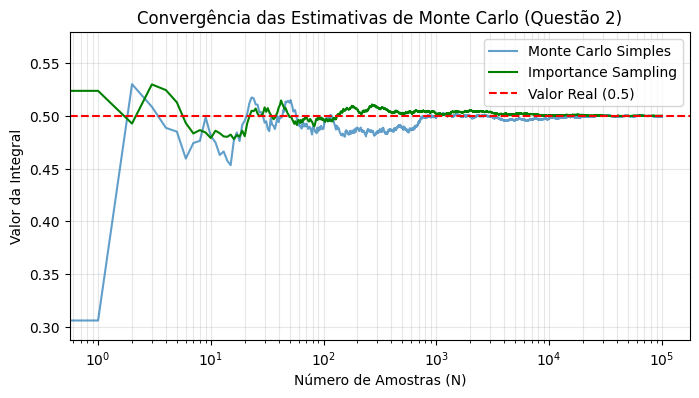

In [ ]:
#(c) Reescreva o estimador e calcule a integral.

# parametros
N = 100000
valor_real = 0.5

# --- MÉTODO A: MONTE CARLO SIMPLES (Questão 2a) ---
u_simples = np.random.uniform(0, 1, N) 
f_u = 1 / (1 + u_simples)**2
estimativa_simples = np.mean(f_u)

# --- MÉTODO B: IMPORTANCE SAMPLING (Questão 2c) ---
u_is = np.random.uniform(0, 1, N)
# Gerando X via Método da Inversa para p(x) = 2/3(2-x)
x_is = 2 - np.sqrt(4 - 3 * u_is) 
f_x = 1 / (1 + x_is)**2      # Função original
p_x = (2/3) * (2 - x_is)     # distribuição escolhida (Questão 2b)
pesos = f_x / p_x            # Estimador reescrito 
estimativa_is = np.mean(pesos)

print(f"Estimativa MC Simples: {estimativa_simples:.6f}")
print(f"Estimativa Importance Sampling: {estimativa_is:.6f}")

# GRÁFICO de convergência para ambos os métodos
plt.figure(figsize=(8, 4))
# Cálculo da convergência (média acumulada) para o gráfico
plt.plot(np.cumsum(f_u) / np.arange(1, N + 1), label='Monte Carlo Simples', alpha=0.7)
plt.plot(np.cumsum(pesos) / np.arange(1, N + 1), label='Importance Sampling', color='green')
plt.axhline(y=valor_real, color='red', linestyle='--', label=f'Valor Real ({valor_real})')
plt.xscale('log') 
plt.title('Convergência das Estimativas de Monte Carlo (Questão 2)')
plt.xlabel('Número de Amostras (N)')
plt.ylabel('Valor da Integral')
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

Final Monte Carlo Simples: 0.499809
Final Importance Sampling: 0.499859


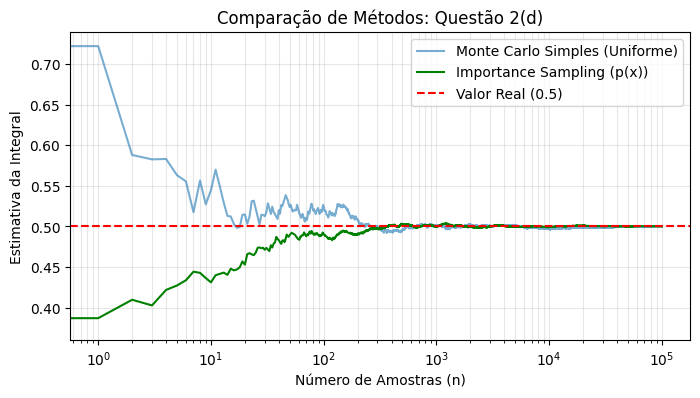

In [ ]:
#(d) Compare os métodos.

#Parâmetros 
N = 100000
valor_real = 0.5

# Monte Carlo Simples Questão 2 na opção a
u_unif = np.random.uniform(0, 1, N)
f_unif = 1 / (1 + u_unif)**2
estimativa_simples = np.cumsum(f_unif) / np.arange(1, N + 1)
print(f"Final Monte Carlo Simples: {estimativa_simples[-1]:.6f}")


#Importance Sampling na Questão 2 na opção c
u = np.random.uniform(0, 1, N)
x = 2 - np.sqrt(4 - 3 * u) # Método da Inversa para p(x)=2/3(2-x)
p_x = (2/3) * (2 - x)
f_x = 1 / (1 + x)**2
razao = f_x / p_x
estimativa_IS = np.cumsum(razao) / np.arange(1, N + 1)
print(f"Final Importance Sampling: {estimativa_IS[-1]:.6f}")

#O Gráfico comparativo
plt.figure(figsize=(8, 4))
plt.plot(estimativa_simples, label='Monte Carlo Simples (Uniforme)', alpha=0.6)
plt.plot(estimativa_IS, label='Importance Sampling (p(x))', color='green')
plt.axhline(y=valor_real, color='red', linestyle='--', label=f'Valor Real ({valor_real})')
plt.xscale('log')
plt.title('Comparação de Métodos: Questão 2(d)')
plt.xlabel('Número de Amostras (n)')
plt.ylabel('Estimativa da Integral')
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()


Variância (Simples): 0.041404
Variância (Importance Sampling): 0.011766
Redução de Variância: 71.58%


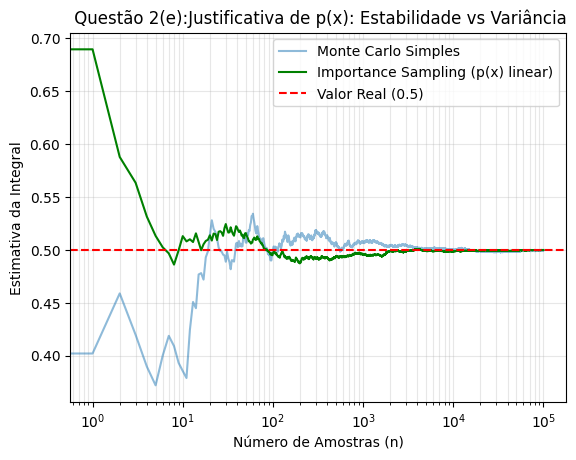

In [56]:
# e) Justifique a escolha de p(x).

#Parâmetros
N = 100000
valor_real = 0.5

#MÉTODO A: MONTE CARLO SIMPLES (Uniforme)
u_unif = np.random.uniform(0, 1, N)
f_unif = 1 / (1 + u_unif)**2
estimativa_simples = np.cumsum(f_unif) / np.arange(1, N + 1)
var_simples = np.var(f_unif)

#MÉTODO B: IMPORTANCE SAMPLING (Justificado em e) ---
u = np.random.uniform(0, 1, N)
x = 2 - np.sqrt(4 - 3 * u) #Gerado via Inversa 
p_x = (2/3) * (2 - x)
f_x = 1 / (1 + x)**2
razao = f_x / p_x
estimativa_IS = np.cumsum(razao) / np.arange(1, N + 1)
var_is = np.var(razao)

# print dos resultados 
print(f"Variância (Simples): {var_simples:.6f}")
print(f"Variância (Importance Sampling): {var_is:.6f}")
print(f"Redução de Variância: {((var_simples - var_is) / var_simples * 100):.2f}%")

#grafico comparativo para mostrar a estabilidade da estimativa com a escolha de p(x)
plt.plot(estimativa_simples, label='Monte Carlo Simples', alpha=0.5)
plt.plot(estimativa_IS, label='Importance Sampling (p(x) linear)', color='green')
plt.axhline(y=valor_real, color='red', linestyle='--', label='Valor Real (0.5)')
plt.xscale('log')
plt.title(' Questão 2(e):Justificativa de p(x): Estabilidade vs Variância')
plt.xlabel('Número de Amostras (n)')
plt.ylabel('Estimativa da Integral')
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()